In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q transformers datasets jiwer evaluate matplotlib

import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from PIL import Image
from transformers import (
    TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator
)
import evaluate

# Load training annotations
train_df = pd.read_csv('/content/drive/MyDrive/words/train.txt', sep="\t", header=None, names=["file_name", "text"])
train_df['file_name'] = train_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)

# Load test annotations
test_df = pd.read_csv('/content/drive/MyDrive/words/test.txt', sep="\t", header=None, names=["file_name", "text"])
test_df['file_name'] = test_df['file_name'].apply(lambda x: x + 'g' if x.endswith('jp') else x)


# Define CustomDataset class
class CustomDataset(Dataset):
    def __init__(self, root_dir, df, processor, max_target_length=128):
        self.root_dir = root_dir
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_name = self.df.iloc[idx]['file_name']
        text = self.df.iloc[idx]['text']
        image_path = f"{self.root_dir}/{file_name}"

        # Load image and preprocess
        image = Image.open(image_path).convert("RGB")
        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        # Encode labels (text)
        labels = self.processor.tokenizer(
            text, padding="max_length", max_length=self.max_target_length, truncation=True
        ).input_ids
        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return {"pixel_values": pixel_values.squeeze(0), "labels": torch.tensor(labels)}


# Load processor and model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-stage1")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-stage1")

# Adjust model configurations
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# Adjust beam search & decoding settings
model.config.eos_token_id = processor.tokenizer.sep_token_id
model.config.max_length = 64
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3
model.config.length_penalty = 2.0
model.config.num_beams = 4

# Load datasets
train_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/train', df=train_df, processor=processor)
eval_dataset = CustomDataset(root_dir='/content/drive/MyDrive/words/test', df=test_df, processor=processor)

# Training arguments with reduced learning rate & mixed precision
training_args = Seq2SeqTrainingArguments(
    output_dir="./trocr_model",         # Model save path
    per_device_train_batch_size=4,      # Reduce batch size (low RAM)
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    learning_rate=1e-5,                 # Reduced learning rate for stability
    weight_decay=0.1,
    fp16=True,                          # Enable mixed precision
    gradient_accumulation_steps=4,      # Effective batch size = 4x4 = 16
    evaluation_strategy="epoch",
    logging_steps=1,
    save_strategy="epoch",              # Save model after every epoch
    save_total_limit=3,
    predict_with_generate=True,
    remove_unused_columns=False
)

# Define evaluation metrics
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids = pred.predictions

    pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)

    cer = cer_metric.compute(predictions=pred_str, references=label_str)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)

    # Calculate Accuracy
    correct = sum([1 if p == t else 0 for p, t in zip(pred_str, label_str)])
    accuracy = correct / len(label_str) if len(label_str) > 0 else 0

    return {"cer": cer, "wer": wer, "accuracy": accuracy}

# Store metrics for visualization
train_losses = []
eval_losses = []
cer_scores = []
wer_scores = []
accuracy_scores = []

# Custom Trainer with Logging
class CustomTrainer(Seq2SeqTrainer):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            print("Logging:", logs)
            if "loss" in logs:
                train_losses.append(logs["loss"])
            if "eval_loss" in logs:
                eval_losses.append(logs["eval_loss"])
            if "cer" in logs:
                cer_scores.append(logs["cer"])
            if "wer" in logs:
                wer_scores.append(logs["wer"])
            if "accuracy" in logs:
                accuracy_scores.append(logs["accuracy"])
    def training_step(self, model, inputs, num_items_in_batch=None):
        # Remove 'num_items_in_batch' from inputs
       inputs.pop("num_items_in_batch", None)
       return super().training_step(model, inputs)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=processor,  # Use processor for tokenization
    data_collator=default_data_collator,
    compute_metrics=compute_metrics
)

# Start training
trainer.train()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.0 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

...

<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 210115 (23024-tkm-college-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss,Cer,Wer,Accuracy
1,5.240300,1.351635,0.165094,0.333333,0.659574
2,3.682700,1.201102,0.136792,0.312500,0.680851
3,3.083100,0.976499,0.051887,0.166667,0.829787
4,2.549300,1.025254,0.075472,0.187500,0.829787
5,2.591200,0.938942,0.056604,0.166667,0.829787
6,2.258900,0.976065,0.080189,0.187500,0.808511
7,2.172600,0.928093,0.061321,0.187500,0.808511
8,2.150000,0.926415,0.047170,0.166667,0.829787
9,1.860800,0.936386,0.051887,0.166667,0.829787
10,2.065200,0.956863,0.051887,0.166667,0.829787


/usr/local/lib/python3.11/dist-packages/transformers/generation/utils.py:1528: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:2758: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 64, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


TrainOutput(global_step=140, training_loss=4.525305357149669, metrics={'train_runtime': 1104.3427, 'train_samples_per_second': 2.01, 'train_steps_per_second': 0.127, 'total_flos': 1.964467900467118e+18, 'train_loss': 4.525305357149669, 'epoch': 10.0})

In [ ]:
model_save_path = "/content/drive/MyDrive/trocr_model"

# Save model
model.save_pretrained(model_save_path)

# Save processor
processor.save_pretrained(model_save_path)

print(f"Model and processor saved to {model_save_path}")


Model and processor saved to /content/drive/MyDrive/trocr_model


In [ ]:
eval_metrics = trainer.evaluate()
print("Evaluation Metrics:", eval_metrics)

if "eval_loss" in eval_metrics:
    eval_losses.append(eval_metrics["eval_loss"])
if "cer" in eval_metrics:
    cer_scores.append(eval_metrics["cer"])
if "wer" in eval_metrics:
    wer_scores.append(eval_metrics["wer"])
if "accuracy" in eval_metrics:
    accuracy_scores.append(eval_metrics["accuracy"])

Evaluation Metrics: {'eval_loss': 0.9568629264831543, 'eval_cer': 0.05188679245283019, 'eval_wer': 0.16666666666666666, 'eval_accuracy': 0.8297872340425532, 'eval_runtime': 10.2569, 'eval_samples_per_second': 4.582, 'eval_steps_per_second': 1.17, 'epoch': 10.0}


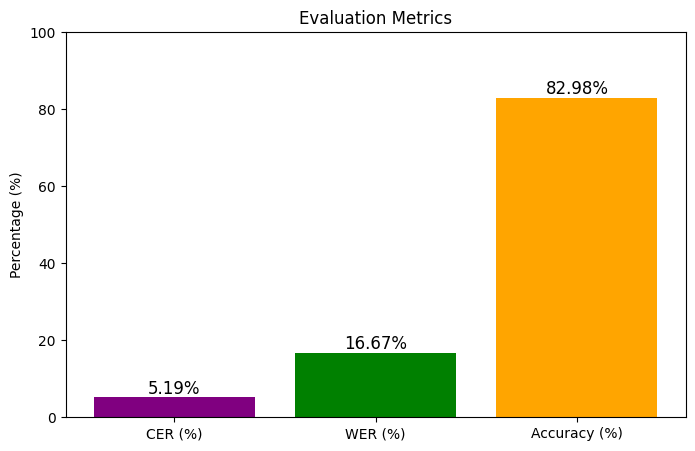

In [ ]:
import matplotlib.pyplot as plt

# Evaluation metrics
metrics = {
    "CER (%)":0.05188679245283019 * 100,  # Convert to %
    "WER (%)": 0.16666666666666666 * 100,  # Convert to %
    "Accuracy (%)": 0.8297872340425532 * 100  # Convert to %
}

# Plot
plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values(), color=["purple", "green", "orange"])
plt.ylabel("Percentage (%)")
plt.title("Evaluation Metrics")

# Show values on bars
for i, value in enumerate(metrics.values()):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center", fontsize=12)

plt.ylim(0, 100)  # Ensure y-axis is within 0-100%
plt.show()

Evaluation Metrics: {'eval_loss': 0.9568629264831543, 'eval_cer': 0.05188679245283019, 'eval_wer': 0.16666666666666666, 'eval_accuracy': 0.8297872340425532, 'eval_runtime': 7.1672, 'eval_samples_per_second': 6.558, 'eval_steps_per_second': 1.674, 'epoch': 10.0}
🔹 Prediction: and
✅ Actual: and

🔹 Prediction: witten
✅ Actual: written

🔹 Prediction: up
✅ Actual: up

🔹 Prediction: and
✅ Actual: and

🔹 Prediction: Theries.
✅ Actual: Thirties.



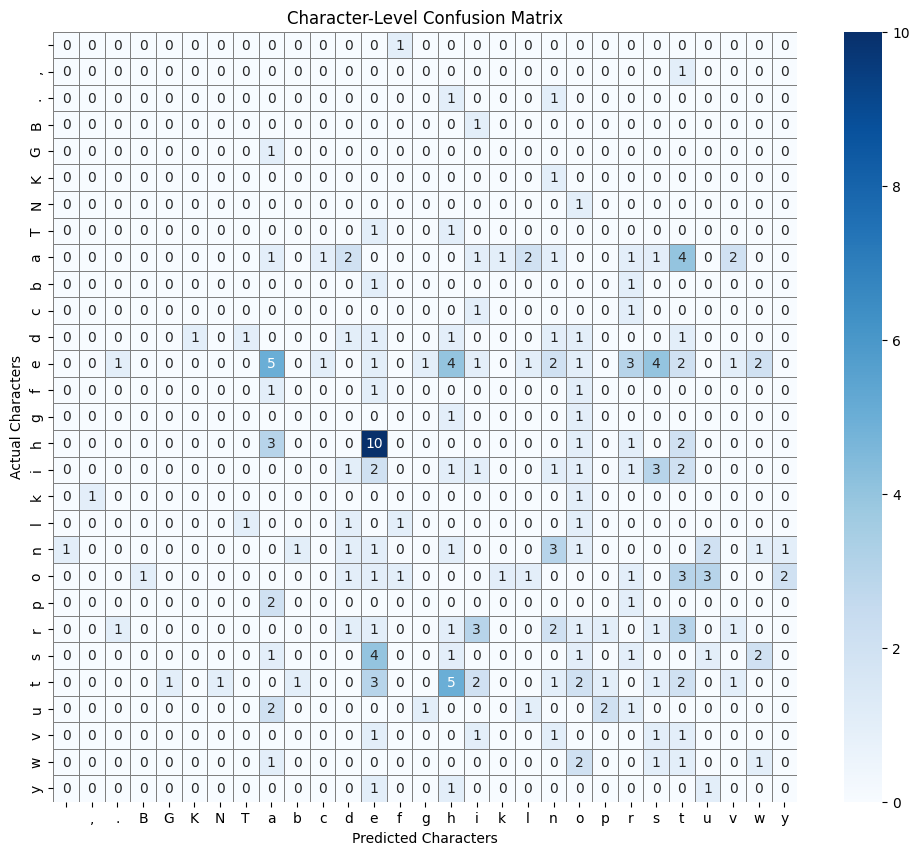

In [ ]:
!pip install scikit-learn matplotlib

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

def plot_confusion_matrix(predictions, references):
    """
    Plots a character-level confusion matrix for OCR predictions.
    """
    # Convert words to character lists
    pred_chars = list("".join(predictions))
    ref_chars = list("".join(references))

    # Ensure the lists have the same length
    min_length = min(len(pred_chars), len(ref_chars))
    pred_chars, ref_chars = pred_chars[:min_length], ref_chars[:min_length]

    # Encode characters into numerical labels
    label_encoder = LabelEncoder()
    unique_chars = sorted(set(pred_chars + ref_chars))  # Unique characters, sorted for consistency
    label_encoder.fit(unique_chars)

    y_true = label_encoder.transform(ref_chars)
    y_pred = label_encoder.transform(pred_chars)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(unique_chars)))

    # Plot the confusion matrix
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                linewidths=0.5, linecolor="gray")

    plt.xlabel("Predicted Characters")
    plt.ylabel("Actual Characters")
    plt.title("Character-Level Confusion Matrix")
    plt.show()

# --- Evaluation & Predictions ---
eval_metrics = trainer.evaluate()
print("Evaluation Metrics:", eval_metrics)

eval_results = trainer.predict(eval_dataset)  # Ensure `eval_dataset` is defined
pred_ids = eval_results.predictions
label_ids = eval_results.label_ids

# Convert token IDs to text
pred_str = processor.batch_decode(pred_ids, skip_special_tokens=True)
label_ids[label_ids == -100] = processor.tokenizer.pad_token_id  # Replace ignored tokens
label_str = processor.batch_decode(label_ids, skip_special_tokens=True)

# Display first few examples for debugging
for i in range(5):
    print(f"🔹 Prediction: {pred_str[i]}")
    print(f"✅ Actual: {label_str[i]}\n")

# Plot confusion matrix
plot_confusion_matrix(pred_str, label_str)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

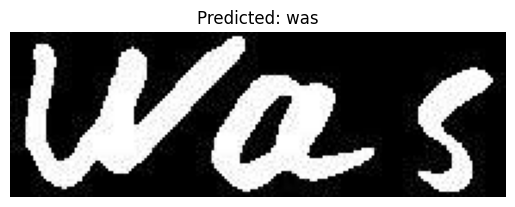

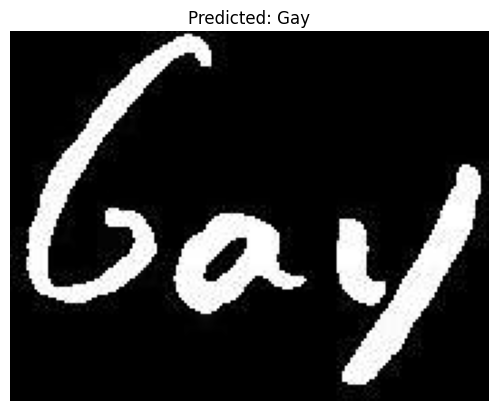

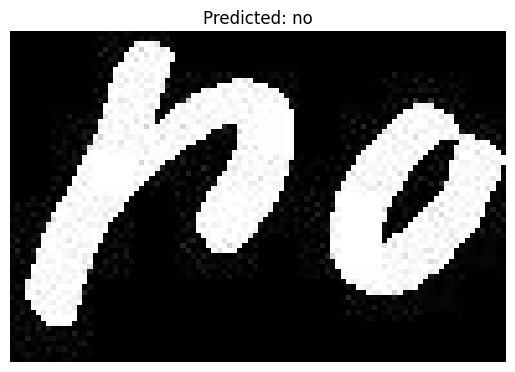

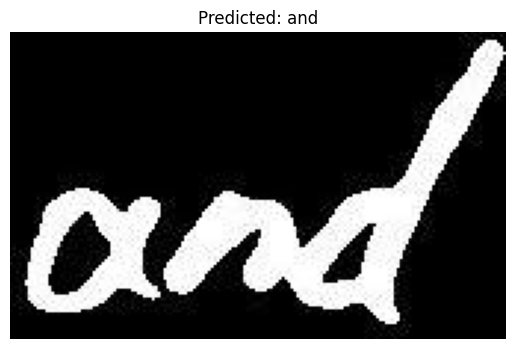

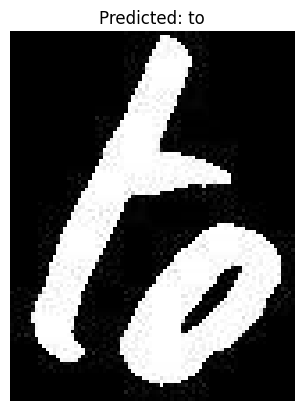

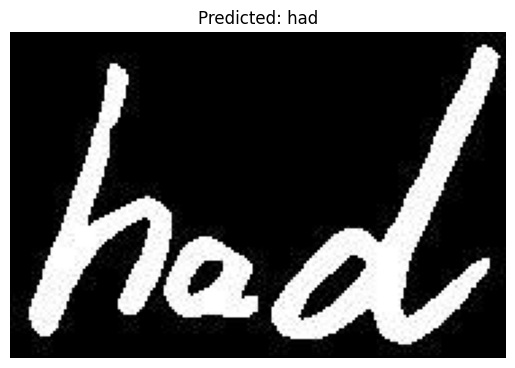

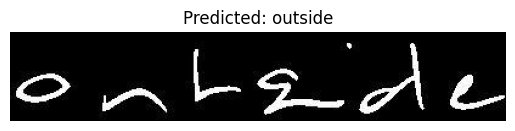

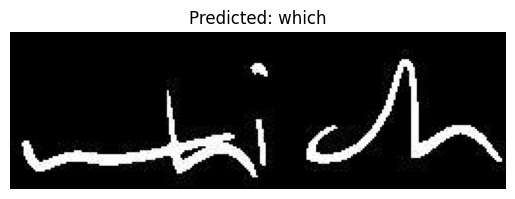

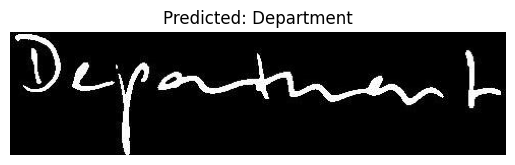

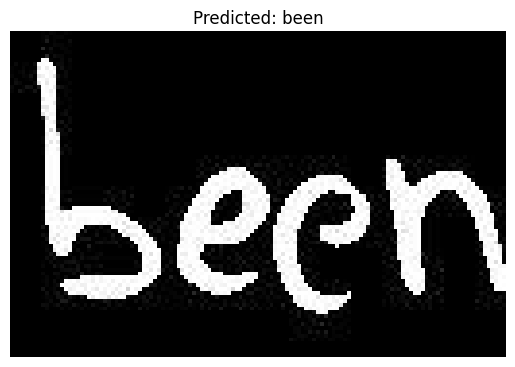

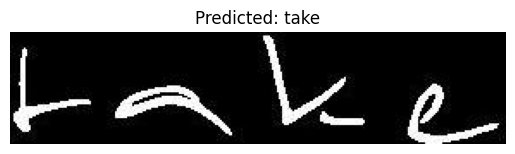

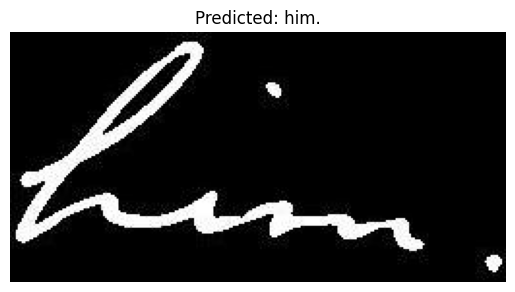

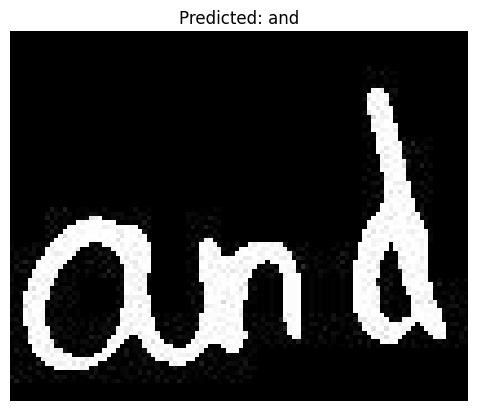

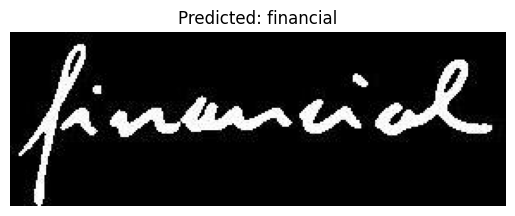

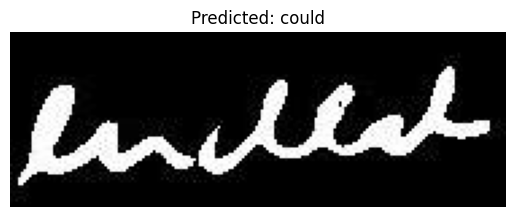

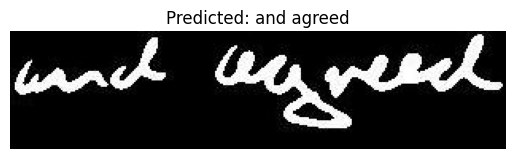

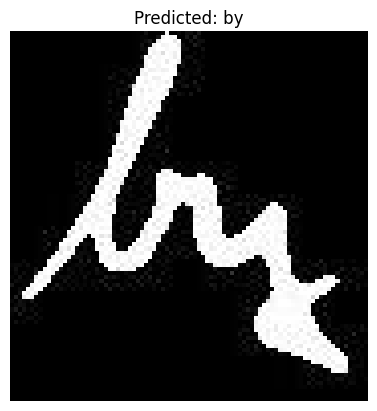

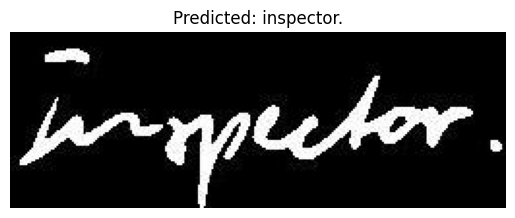

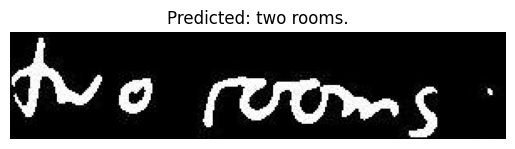

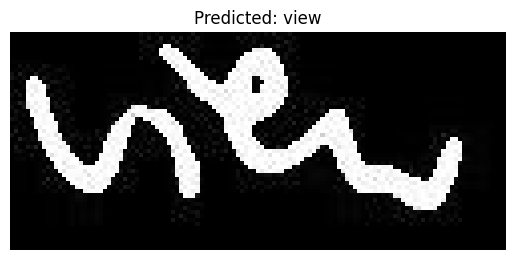

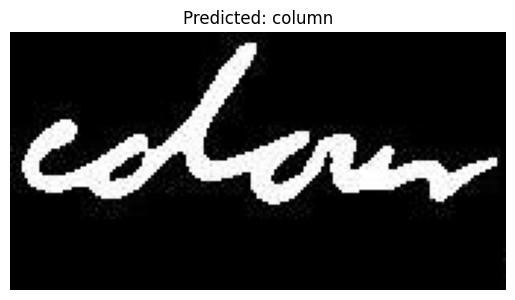

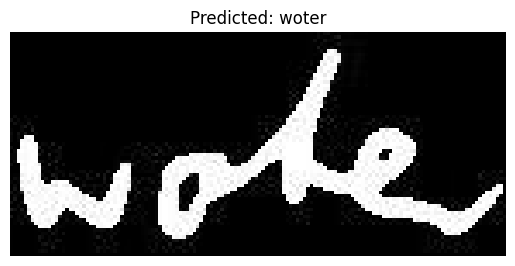

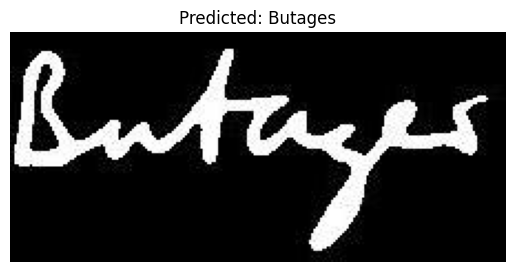

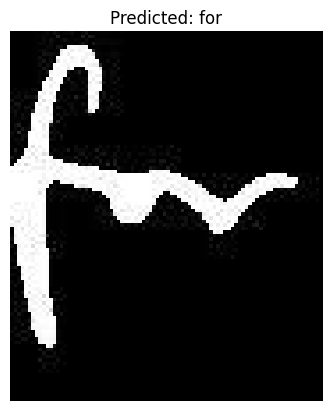

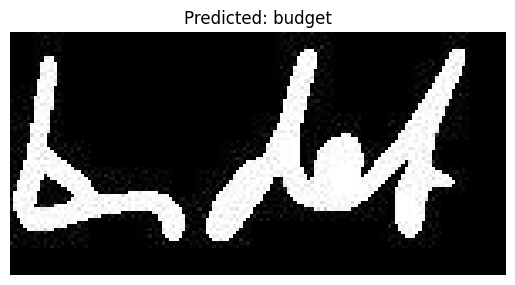

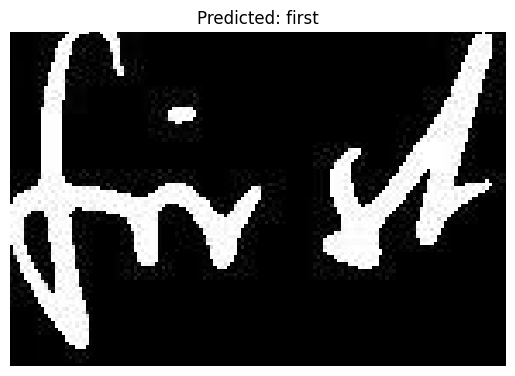

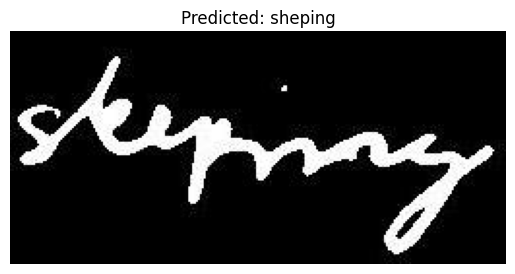

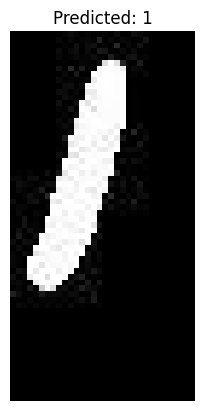

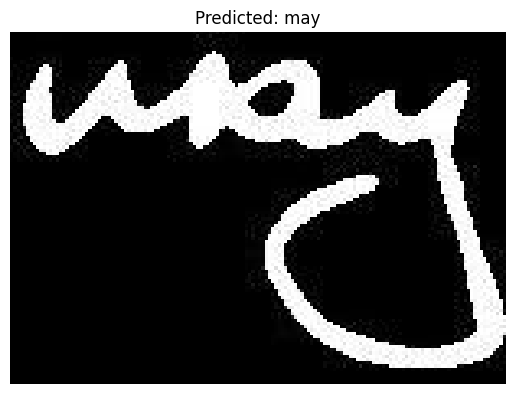

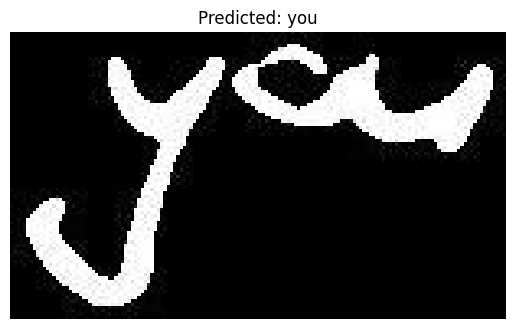

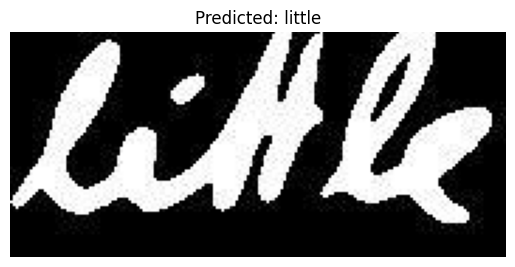

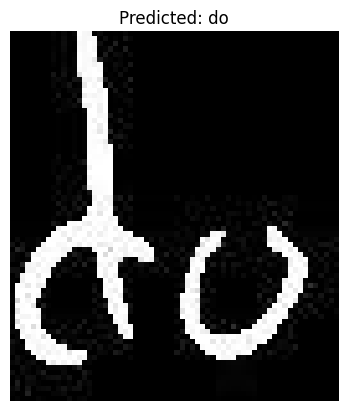

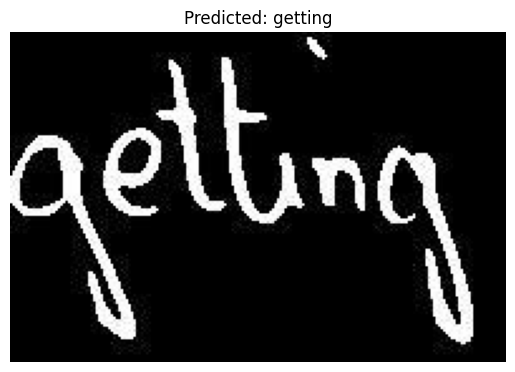

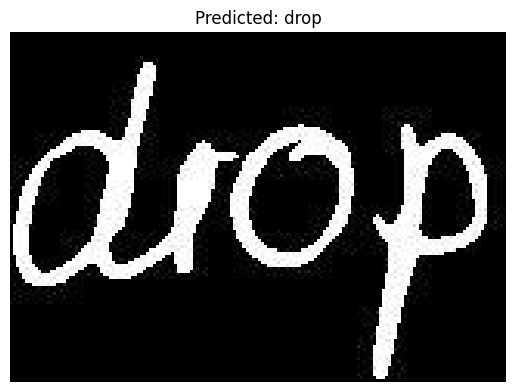

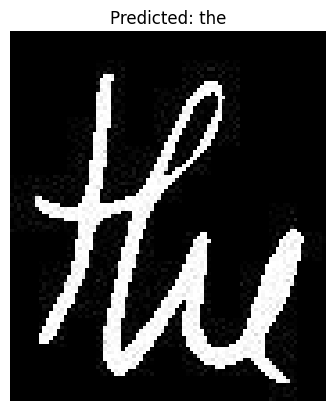

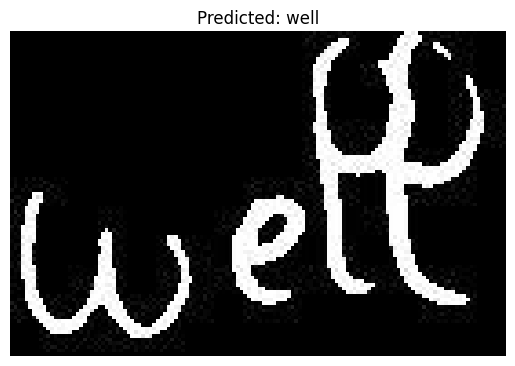

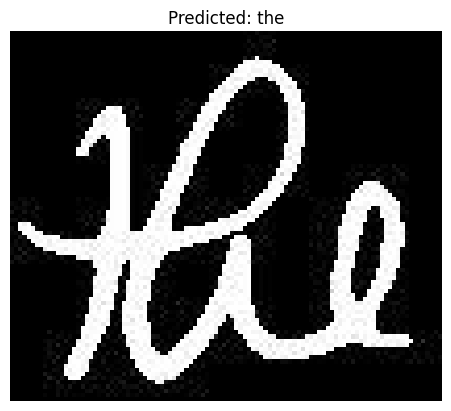

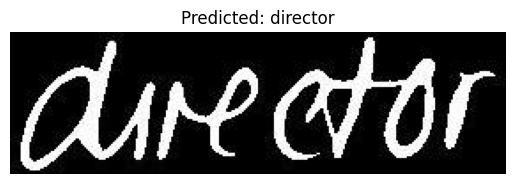

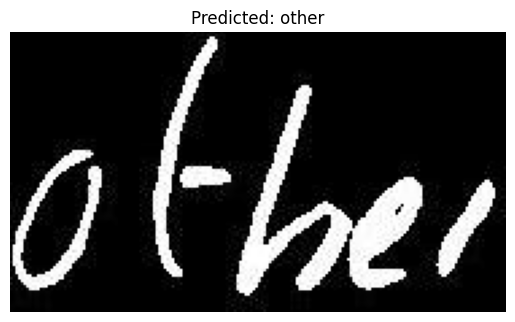

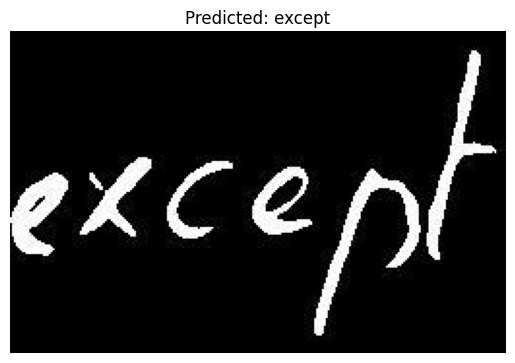

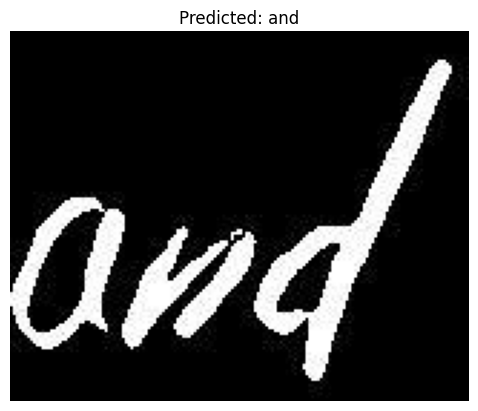

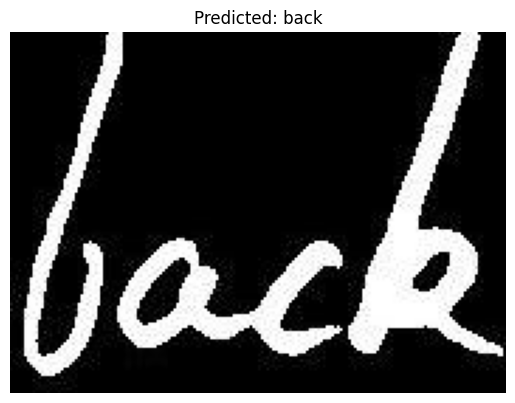

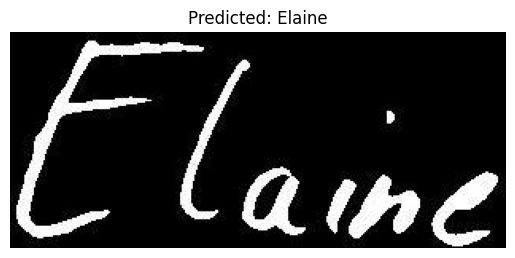

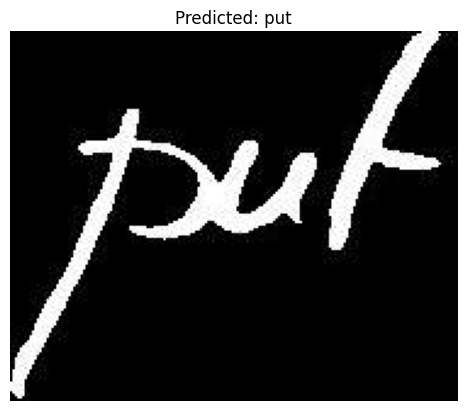

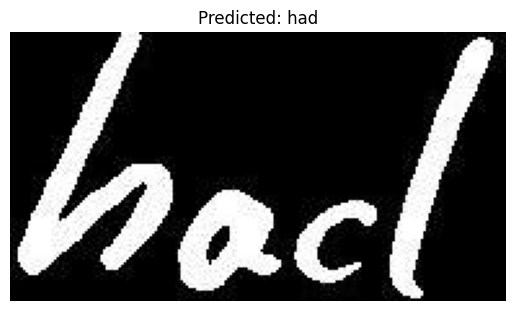

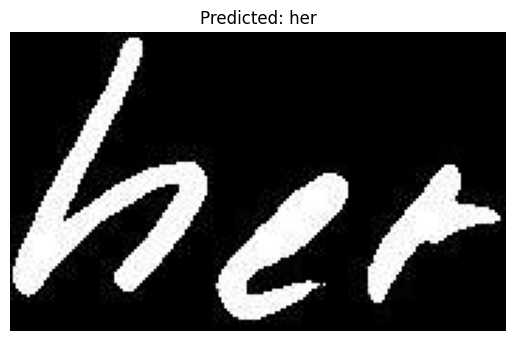

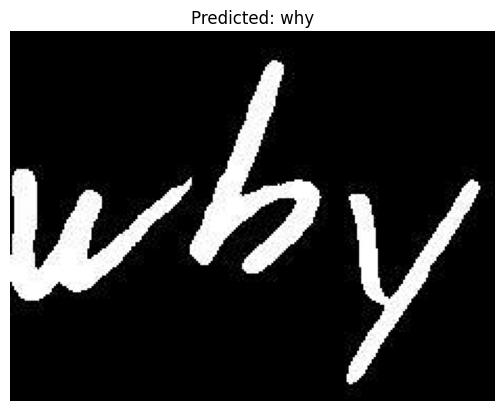

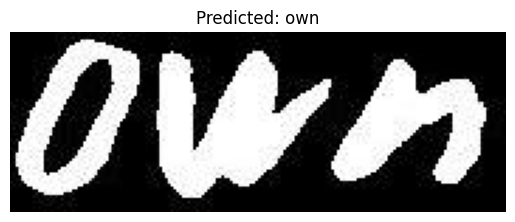

In [ ]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
import torch
from PIL import Image
import matplotlib.pyplot as plt

from datasets import load_dataset

validation_dataset = load_dataset("imagefolder", data_dir="/content/drive/MyDrive/words/validation")  # ✅ Load dataset



# Load the trained model and processor
model_path = "/content/drive/MyDrive/trocr_model"
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Function to predict text from an image
def recognize_text(image):
    # Ensure image is RGB
    if isinstance(image, str):  # If it's a file path, open it
        image = Image.open(image).convert("RGB")
    elif isinstance(image, Image.Image):  # If it's a PIL image, convert to RGB
        image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return predicted_text, image

# Test on validation images
for i in range(48):  # Test 5 samples
    img = validation_dataset["train"][i]["image"]  # Load image

    pred_text, img_rgb = recognize_text(img)  # Get prediction & image

    # Display the image
    plt.imshow(img_rgb)
    plt.axis("off")  # Hide axes
    plt.title(f"Predicted: {pred_text}")
    plt.show()

In [ ]:
import torch
import ipywidgets as widgets
from IPython.display import display
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import io

# Load your pretrained model and processor
model_path = "/content/drive/MyDrive/trocr_model"  # Update this to your saved model path
processor = TrOCRProcessor.from_pretrained(model_path)
model = VisionEncoderDecoderModel.from_pretrained(model_path)

# Set model to evaluation mode
model.eval()

# Function to recognize text from an image
def recognize_text(image):
    # Convert uploaded file to PIL image
    image = Image.open(image).convert("RGB")

    # Preprocess the image
    pixel_values = processor(image, return_tensors="pt").pixel_values

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    pixel_values = pixel_values.to(device)

    # Generate prediction
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    # Decode the predicted text
    predicted_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return predicted_text

# Upload widget
upload = widgets.FileUpload(accept="image/*", multiple=False)
display(upload)

# Button to process uploaded image
def on_upload_change(change):
    for file in upload.value:
        img = io.BytesIO(upload.value[file]['content'])
        recognized_text = recognize_text(img)
        print("\n📝 Recognized Text:", recognized_text)

upload.observe(on_upload_change, names="value")


Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.3"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared decoder config: TrOCRConfig {
  "activation_dropout": 0.0,
  "activation_function": "relu",
  "add_cross_attention": true,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "classifier_dropout": 0.0,
  "cross_attention_hidden_size": 768,
  "d_model": 1024,
  "decoder_attention_heads": 16,
  "decoder_ffn_dim": 4096,
  "decoder

FileUpload(value={}, accept='image/*', description='Upload')


📝 Recognized Text: orange

📝 Recognized Text: suasting

📝 Recognized Text: hamony

📝 Recognized Text: zebra

📝 Recognized Text: design

📝 Recognized Text: Hisham

📝 Recognized Text: savawayty

📝 Recognized Text: signstanding

📝 Recognized Text: springline

📝 Recognized Text: chuitanga

📝 Recognized Text: THE

📝 Recognized Text: sets

📝 Recognized Text: only

📝 Recognized Text: the

📝 Recognized Text: ====


In [ ]:
import os

val_dataset_path = "/content/drive/MyDrive/words/validation"
image_files = [f for f in os.listdir(val_dataset_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]

print("Found images:", image_files)


Found images: ['0263.png', '0325.png', '0131.png', '0161.png', '0167.png', '0156.png', '0140.png', '0058.png', '0194.png', '0012.png', '0010.png', '0137.png', '0001.png', '0165.png', '0154.png', '0283.png', '0253.png', '0207.png', '0300.png', '0275.png', '0008.png', '0210.png', '0077.png', '0004.png', '0172.png', '0163.png', '0134.png', '0191.png', '0103.png', '0157.png', '0236.png', '0273.png', '0323.png', '0209.png', '0244.png', '0138.png', '0174.png', '0036.png', '0295.png', '0322.png', '0054.png', '0233.png', '0241.png', '0079.png', '0136.png', '0023.png', '0281.png', '0306.png']


In [ ]:
for img_file in image_files:
    img_path = os.path.join(val_dataset_path, img_file)
    print(f"Processing: {img_path}")  # Add this to see if images are being processed

    extracted_text = extract_text(img_path)

    if extracted_text["paddle_ocr"] or extracted_text["trocr"]:  # Ensure some text was extracted
        results[img_file] = extracted_text
    else:
        print(f"No text found in {img_file}")


Processing: /content/drive/MyDrive/words/validation/0263.png
[2025/02/25 07:13:09] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.030538320541381836
[2025/02/25 07:13:09] ppocr DEBUG: rec_res num  : 1, elapsed : 0.08080220222473145
Processing: /content/drive/MyDrive/words/validation/0325.png
[2025/02/25 07:13:14] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.045291900634765625
[2025/02/25 07:13:14] ppocr DEBUG: rec_res num  : 1, elapsed : 0.14746975898742676
Processing: /content/drive/MyDrive/words/validation/0131.png
[2025/02/25 07:13:19] ppocr DEBUG: dt_boxes num : 1, elapsed : 0.03153538703918457
[2025/02/25 07:13:20] ppocr DEBUG: rec_res num  : 1, elapsed : 0.11538958549499512
Processing: /content/drive/MyDrive/words/validation/0161.png
[2025/02/25 07:13:23] ppocr DEBUG: dt_boxes num : 0, elapsed : 0.05946540832519531
[2025/02/25 07:13:23] ppocr DEBUG: rec_res num  : 0, elapsed : 1.6689300537109375e-06
Processing: /content/drive/MyDrive/words/validation/0167.png
[2025/02/25 07:13:25] ppoc

In [ ]:
for img_file in image_files:
    img_path = os.path.join(val_dataset_path, img_file)
    print(f"Processing: {img_path}")  # Add this to see if images are being processed

    extracted_text = extract_text(img_path)

    if extracted_text["paddle_ocr"] or extracted_text["trocr"]:  # Ensure some text was extracted
        results[img_file] = extracted_text
    else:
        print(f"No text found in {img_file}")


In [ ]:
def extract_text(image_path):
    # Perform OCR with PaddleOCR
    ocr_results = ocr.ocr(image_path, cls=False)
    print(f"PaddleOCR Raw Output for {image_path}: {ocr_results}")  # Debugging line

    paddle_texts = []
    if ocr_results:
        for result in ocr_results:
            if result is not None:
                for line in result:
                    print(f"Detected Line: {line}")  # Debugging line
                    _, (text, _) = line  # Extract detected text
                    paddle_texts.append(text)

    # Load image for TrOCR
    image = Image.open(image_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values

    # Perform OCR using TrOCR
    with torch.no_grad():
        generated_ids = model.generate(pixel_values)
    trocr_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print(f"TrOCR Output for {image_path}: {trocr_text}")  # Debugging line

    return {
        "paddle_ocr": " ".join(paddle_texts),
        "trocr": trocr_text
    }
